In [2]:
from core.data_reader import *
import os
from matplotlib import pyplot as plt
import tqdm
import numpy as np

['tasmax_hyras_1_1951_v6-1_de.nc', 'pr_hyras_1_1951_v6-1_de.nc', 'tasmin_hyras_1_1951_v6-1_de.nc', 'tas_hyras_1_1951_v6-1_de.nc', 'tasmax_hyras_1_1952_v6-1_de.nc', 'tas_hyras_1_1952_v6-1_de.nc', 'pr_hyras_1_1952_v6-1_de.nc', 'tasmin_hyras_1_1952_v6-1_de.nc', 'tasmin_hyras_1_1953_v6-1_de.nc', 'pr_hyras_1_1953_v6-1_de.nc', 'tas_hyras_1_1953_v6-1_de.nc', 'tasmax_hyras_1_1953_v6-1_de.nc', 'tasmax_hyras_1_1954_v6-1_de.nc', 'tasmin_hyras_1_1954_v6-1_de.nc', 'pr_hyras_1_1954_v6-1_de.nc', 'tas_hyras_1_1954_v6-1_de.nc', 'pr_hyras_1_1955_v6-1_de.nc', 'tas_hyras_1_1955_v6-1_de.nc', 'tasmax_hyras_1_1955_v6-1_de.nc', 'tasmin_hyras_1_1955_v6-1_de.nc', 'tas_hyras_1_1956_v6-1_de.nc', 'pr_hyras_1_1956_v6-1_de.nc', 'tasmax_hyras_1_1956_v6-1_de.nc', 'tasmin_hyras_1_1956_v6-1_de.nc', 'pr_hyras_1_1957_v6-1_de.nc', 'tasmin_hyras_1_1957_v6-1_de.nc', 'tas_hyras_1_1957_v6-1_de.nc', 'tasmax_hyras_1_1957_v6-1_de.nc', 'tasmin_hyras_1_1958_v6-1_de.nc', 'tasmax_hyras_1_1958_v6-1_de.nc', 'tas_hyras_1_1958_v6-1_de.nc

Processing files: 100%|██████████| 292/292 [03:27<00:00,  1.41it/s]


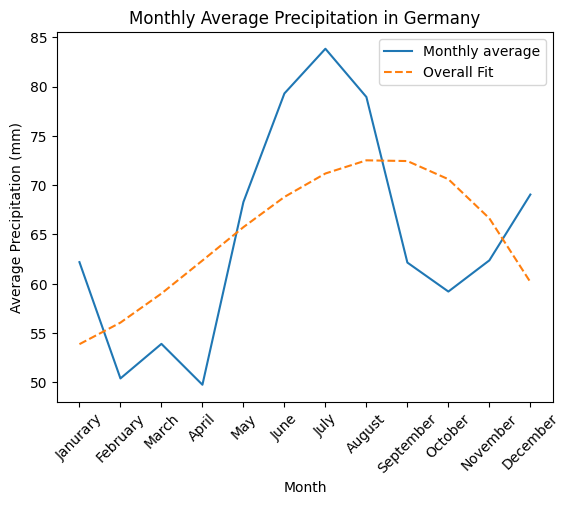

In [ ]:
files = []

for file in os.listdir('.data'):
    if file.endswith('.nc'):
        files.append(file)

files_sorted = sorted(files, key=lambda x: x.split('_')[3])
print(files_sorted)

months = ["Janurary", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

nc_files = [f for f in files_sorted if f.endswith('.nc')]

results = []
for file in tqdm.tqdm(nc_files, desc="Processing files"):
    if not file.endswith('.nc'):
        continue
    if not file.split('_')[0] == "pr":
        continue
    filename = os.path.join('.data', file)
    avg_precip = monthly_total_precipitation_germany(filename)
    results.append(avg_precip)

#for label, data in results:
    #plt.plot(months, data, label=label)

overall_monthly_average_totals = [0 for _ in months]

for i, r in enumerate(results):
    for j, month in enumerate(r):
        overall_monthly_average_totals[j] += month
overall_precipitation = [x / len(results) for x in overall_monthly_average_totals]

fit_curve = np.polyfit(range(len(months)), overall_precipitation, 3)
fit_func = np.poly1d(fit_curve)
plt.plot(months, overall_precipitation, label="Monthly average")
plt.plot(months, fit_func(range(len(months))), label='Overall Fit', linestyle='--')
plt.xlabel('Month')
plt.ylabel('Total Precipitation (mm)')
plt.title('Monthly Total Precipitation in Germany')
plt.legend()
plt.xticks(rotation=45)
plt.show()

Processing files: 100%|██████████| 292/292 [03:19<00:00,  1.47it/s]


[('1951', 270252256.0), ('1952', 294652640.0), ('1953', 211733104.0), ('1954', 312870592.0), ('1955', 280030144.0), ('1956', 300187808.0), ('1957', 281312416.0), ('1958', 311798912.0), ('1959', 196027776.0), ('1960', 303738688.0), ('1961', 308948736.0), ('1962', 249253184.0), ('1963', 235832944.0), ('1964', 227275552.0), ('1965', 353459680.0), ('1966', 345959392.0), ('1967', 297165440.0), ('1968', 300515776.0), ('1969', 258027296.0), ('1970', 325690912.0), ('1971', 214706752.0), ('1972', 235815728.0), ('1973', 250871600.0), ('1974', 315925920.0), ('1975', 235369632.0), ('1976', 211165456.0), ('1977', 294277056.0), ('1978', 286194752.0), ('1979', 294921728.0), ('1980', 299574752.0), ('1981', 354729984.0), ('1982', 251264224.0), ('1983', 280155072.0), ('1984', 294419200.0), ('1985', 261826416.0), ('1986', 308470144.0), ('1987', 315366080.0), ('1988', 310615744.0), ('1989', 245146816.0), ('1990', 282413952.0), ('1991', 229648928.0), ('1992', 283174976.0), ('1993', 315117248.0), ('1994', 3

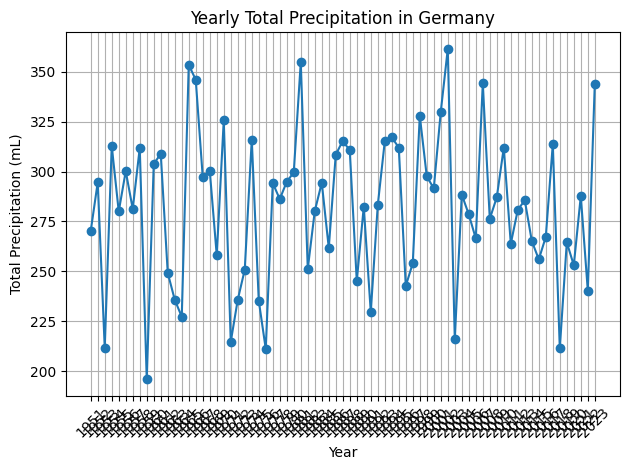

In [ ]:
yearly_precipitation = []
for file in tqdm.tqdm(files_sorted, desc="Processing files"):
    filename = os.path.join('.data', file)
    if not file.endswith('.nc'):
        continue
    if not file.split('_')[0] == "pr":
        continue
    yearly_precipitation.append((file.split('_')[3], total_precipitation(filename)))

print(yearly_precipitation)

plt.plot([x for x in range(1951, 2024)], [x/1_000_000 for x in yearly_precipitation], marker='o')
plt.xlabel('Year')
plt.ylabel('Total Precipitation (mL)')
plt.title('Yearly Total Precipitation in Germany')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

Year: 1951, Potato Yield: 24330307.0 tons
Year: 1952, Potato Yield: 24069653.0 tons
Year: 1953, Potato Yield: 24786716.0 tons
Year: 1954, Potato Yield: 27066702.0 tons
Year: 1955, Potato Yield: 23094119.0 tons
Year: 1956, Potato Yield: 27013722.0 tons
Year: 1957, Potato Yield: 26501510.0 tons
Year: 1958, Potato Yield: 22868412.0 tons
Year: 1959, Potato Yield: 22719950.0 tons
Year: 1960, Potato Yield: 24558918.0 tons
Year: 1961, Potato Yield: 21515630.0 tons
Year: 1962, Potato Yield: 25103600.0 tons
Year: 1963, Potato Yield: 25812413.0 tons
Year: 1964, Potato Yield: 20623985.0 tons
Year: 1965, Potato Yield: 18094631.0 tons
Year: 1966, Potato Yield: 18839385.0 tons
Year: 1967, Potato Yield: 21293532.0 tons
Year: 1968, Potato Yield: 19195690.0 tons
Year: 1969, Potato Yield: 15984598.0 tons
Year: 1970, Potato Yield: 16250042.0 tons
Year: 1971, Potato Yield: 15176069.0 tons
Year: 1972, Potato Yield: 15038212.0 tons
Year: 1973, Potato Yield: 13676482.0 tons
Year: 1974, Potato Yield: 14548488

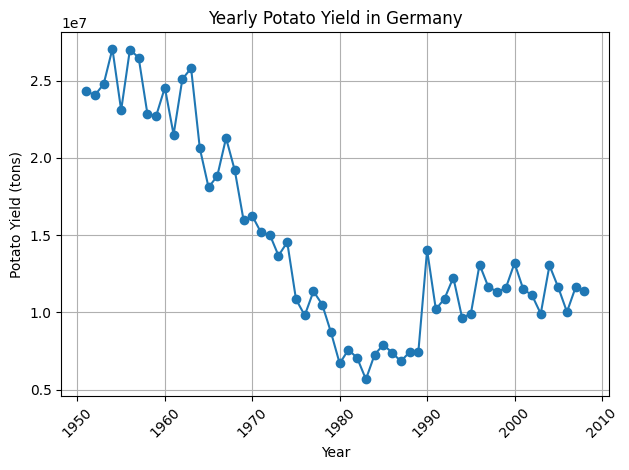

In [ ]:
for i in range(1951, 2009):
    potato_yield = yearly_potato_yield(i)
    print(f"Year: {i}, Potato Yield: {potato_yield} tons")

plt.plot(range(1951, 2009), [yearly_potato_yield(i) for i in range(1951, 2009)], marker='o')
plt.xlabel('Year')
plt.ylabel('Potato Yield (tons)')
plt.title('Yearly Potato Yield in Germany')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

58
58


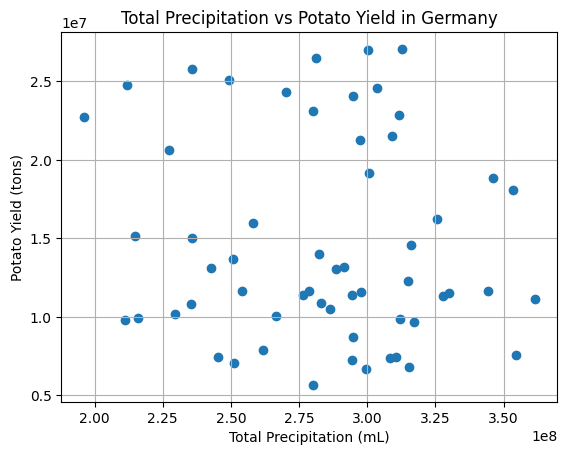

In [ ]:
print(len(yearly_precipitation[:58]))
print(len([yearly_potato_yield(i) for i in range(1951, 2009)]))

plot_tuple_list = []

for i in yearly_precipitation[:58]:
    if yearly_potato_yield(int(i[0])) is not None:
        plot_tuple_list.append((i[1], yearly_potato_yield(int(i[0]))))

plt.scatter([x[0] for x in plot_tuple_list], [x[1] for x in plot_tuple_list])
plt.xlabel('Total Precipitation (mL)')
plt.ylabel('Potato Yield (tons)')
plt.title('Total Precipitation vs Potato Yield in Germany')
plt.grid()
plt.show()

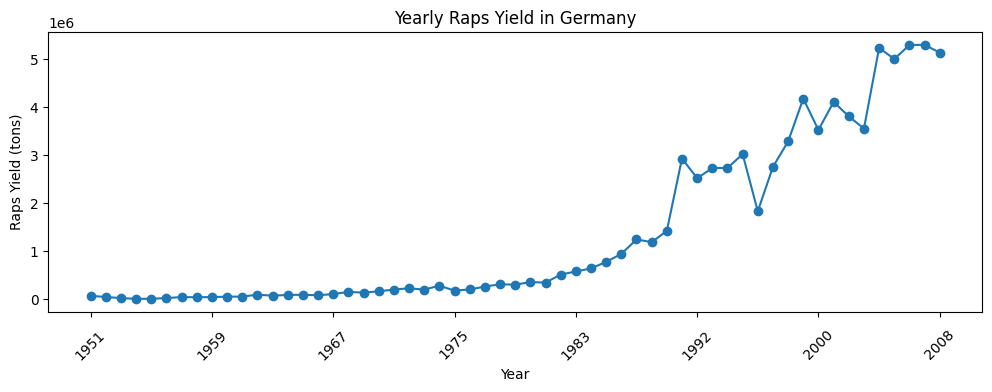

In [ ]:
#print(len(yearly_precipitation[:58]))
#print(len([yearly_raps_yield('.data/41241-0002_de_flat.csv', i) for i in range(1951, 2009)]))

raps_plot_tuple_list = []
for i in yearly_precipitation[:58]:
    try:
        if yearly_raps_yield(int(i[0])) is not None:
                raps_plot_tuple_list.append((i[0], yearly_raps_yield(int(i[0]))))
    except (ValueError, TypeError):
        pass

import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot([x[0] for x in raps_plot_tuple_list], [x[1] for x in raps_plot_tuple_list], marker='o')

ax.set_title('Yearly Raps Yield in Germany')
ax.set_xlabel('Year')
ax.set_ylabel('Raps Yield (tons)')

# choose a reasonable number of ticks
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=10))

# rotate labels and add padding in pixels
ax.tick_params(axis='x', rotation=45, pad=8)

fig.tight_layout(pad=1.0)
plt.show()

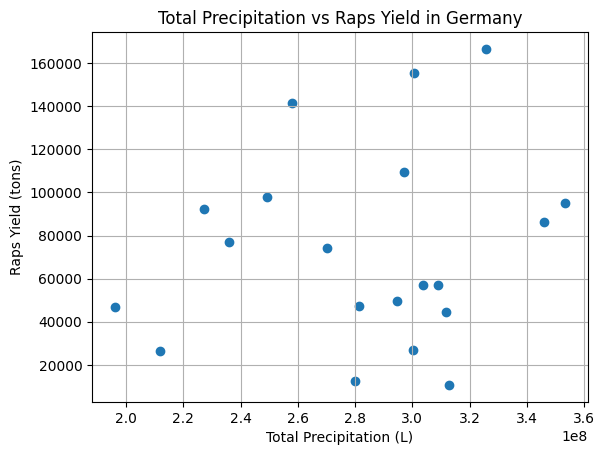

In [ ]:
plot_raps_tuple_list = []

for i in yearly_precipitation[:20]:
    try:
        if yearly_raps_yield(int(i[0])) is not None:
                plot_raps_tuple_list.append((i[1], yearly_raps_yield(int(i[0]))))
    except (ValueError, TypeError):
        pass

plt.scatter([x[0] for x in plot_raps_tuple_list], [x[1] for x in plot_raps_tuple_list])
plt.xlabel('Total Precipitation (L)')
plt.ylabel('Raps Yield (tons)')
plt.title('Total Precipitation vs Raps Yield in Germany')
plt.grid()
plt.show()


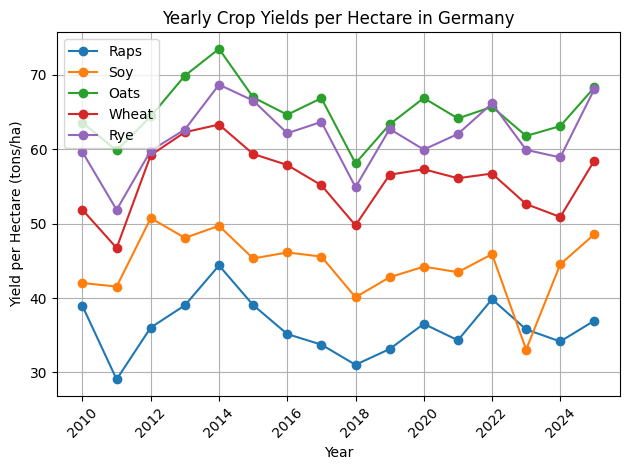

In [ ]:
years = [x for x in range(2010, 2026)]
rape_yields = []
soy_yields = []
oats_yields = []
wheat_yields = []
rye_yields = []
barley_yields = []

for year in years: 
    rape_yields.append(yearly_raps_yield_per_hectare(year))
    #soy_yields.append(yearly_soy_yield_per_hectare(year))
    oats_yields.append(yearly_oats_yield_per_hectare(year))
    wheat_yields.append(yearly_wheat_yield_per_hectare(year))
    rye_yields.append(yearly_rye_yield_per_hectare(year))
    barley_yields.append(yearly_barley_yield_per_hectare(year))

plt.plot(years, rape_yields, marker='o')
#plt.plot(years, soy_yields, marker='o')
plt.plot(years, oats_yields, marker='o')
plt.plot(years, wheat_yields, marker='o')
plt.plot(years, rye_yields, marker='o')
plt.plot(years, barley_yields, marker='o')
plt.legend(['Raps', 'Soy', 'Oats', 'Wheat', 'Rye', 'Barley'])
plt.xlabel('Year')
plt.ylabel('Yield per Hectare (tons/ha)')
plt.title('Yearly Crop Yields per Hectare in Germany')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

100%|██████████| 14/14 [00:38<00:00,  2.74s/it]

14
16
14
14


(array([2.0e+08, 2.2e+08, 2.4e+08, 2.6e+08, 2.8e+08, 3.0e+08, 3.2e+08,
        3.4e+08, 3.6e+08]),
 [Text(200000000.0, 0, '2.0'),
  Text(220000000.0, 0, '2.2'),
  Text(240000000.0, 0, '2.4'),
  Text(260000000.0, 0, '2.6'),
  Text(280000000.0, 0, '2.8'),
  Text(300000000.0, 0, '3.0'),
  Text(320000000.0, 0, '3.2'),
  Text(340000000.0, 0, '3.4'),
  Text(360000000.0, 0, '3.6')])

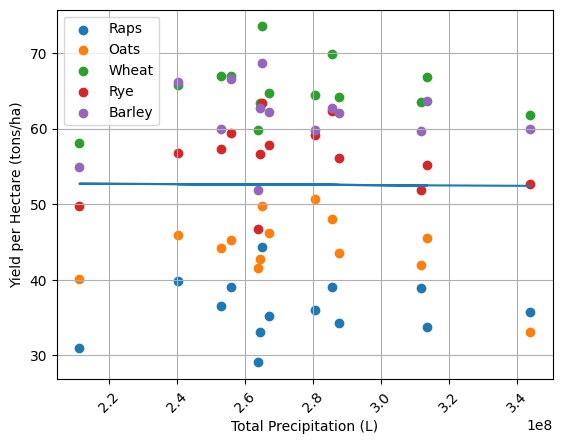

In [ ]:
yearly_precipitation = []

for year in tqdm.tqdm(range(2010, 2024)):
    filename = f".data/pr_hyras_1_{year}_v6-1_de.nc"
    #filename = f'.data/pr_{year}_de_flat.csv'
    if os.path.exists(filename):
        yearly_precipitation.append((year, total_precipitation(filename)))

print(len(yearly_precipitation))
print(len(rape_yields))


plt.scatter([x[1] for x in yearly_precipitation], rape_yields[:len(yearly_precipitation)], marker='o')
plt.scatter([x[1] for x in yearly_precipitation], oats_yields[:len(yearly_precipitation)], marker='o')
plt.scatter([x[1] for x in yearly_precipitation], wheat_yields[:len(yearly_precipitation)], marker='o')
plt.scatter([x[1] for x in yearly_precipitation], rye_yields[:len(yearly_precipitation)], marker='o')
plt.scatter([x[1] for x in yearly_precipitation], barley_yields[:len(yearly_precipitation)], marker='o')
plt.legend(['Raps', 'Oats', 'Wheat', 'Rye', 'Barley'])
plt.xlabel('Total Precipitation (L)')
plt.ylabel('Yield per Hectare (tons/ha)')

avg = []
for i in range(len(oats_yields[:len(yearly_precipitation)])):
    avg.append((rape_yields[i] + oats_yields[i] + wheat_yields[i] + rye_yields[i] + barley_yields[i]) / 5)

print(len(avg))
print(len(yearly_precipitation[:len(avg)]))
fit_curve = np.polyfit([x[1] for x in yearly_precipitation[:len(avg)]], avg, 1)
fit_func = np.poly1d(fit_curve)
plt.plot([x[1] for x in yearly_precipitation], fit_func([x[1] for x in yearly_precipitation]), label='Fit')
#plt.xlabel('Precipitation')
#plt.ylabel('Yield in tons/ha')
#plt.title('Yearly Total Precipitation in Germany')
plt.grid()
plt.xticks(rotation=45)

In [ ]:
avg_temp = []

for i in tqdm.tqdm(range(1951, 2009)):
    filename = f".data/tas_hyras_1_{i}_v6-1_de.nc"
    avg_temp.append(average_monthly_temperature(filename=filename))


100%|██████████| 58/58 [04:46<00:00,  4.93s/it]


(['1951-01', '1951-02', '1951-03', '1951-04', '1951-05', '1951-06', '1951-07', '1951-08', '1951-09', '1951-10', '1951-11', '1951-12'], array([ 1.40196533,  1.81853297,  2.23414933,  7.21794136, 11.44919605,
       15.2423462 , 17.0442511 , 17.1226766 , 14.43443582,  7.26756119,
        6.41620903,  2.43671934]))


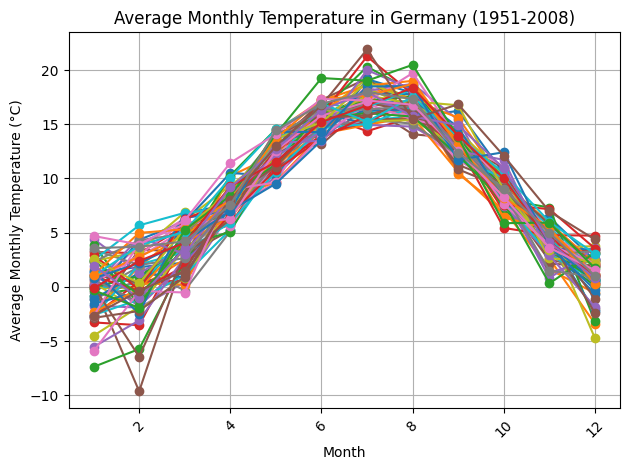

In [ ]:
print(avg_temp[0])

i = 0
for year in range(1951, 2009):
    plt.plot([month for month in range(1, 13)], [x for x in avg_temp[i][1]], marker='o')
    i += 1
plt.xlabel('Month')
plt.ylabel('Average Monthly Temperature (°C)')
plt.title('Average Monthly Temperature in Germany (1951-2008)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [9]:
avg_precip = []

for i in tqdm.tqdm(range(1951, 2009)):
    filename = f".data/pr_hyras_1_{i}_v6-1_de.nc"
    avg_precip.append(monthly_average_precipitation_germany(filename=filename))

100%|██████████| 58/58 [02:49<00:00,  2.92s/it]


[2.45274601 1.61651337 2.16203521 1.38910663 2.16296043 3.36476296
 2.36642793 2.51269984 1.68757023 0.54869397 2.83623173 1.4636365 ]


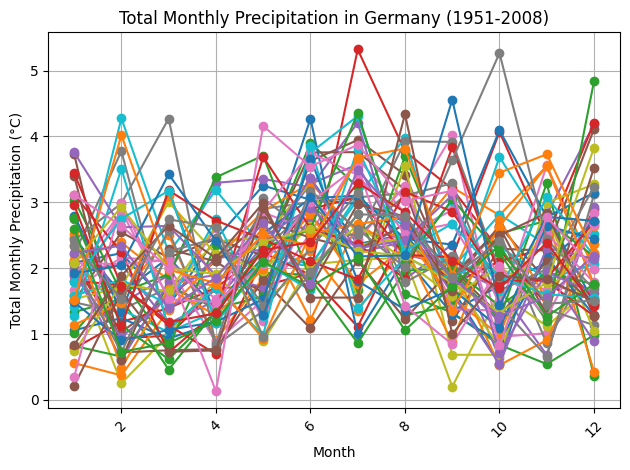

In [11]:
print(avg_precip[0])

for i, year in enumerate(range(1951, 2009)):
    plt.plot([month for month in range(1, 13)], [x for x in avg_precip[i]], marker='o')
plt.xlabel('Month')
plt.ylabel('Total Monthly Precipitation (°C)')
plt.title('Total Monthly Precipitation in Germany (1951-2008)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()